### Sanity Checks

#### Re-referencing

Opening raw data file ../data/sub-01_P1_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Opening raw data file ../data/sub-01_P1_raw_CAR.fif...
Opening raw data file ../data/sub-01_P1_raw_CAR.fif...


C:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\eeg_pipeline\utils.py:10: RuntimeWarning: This filename (../data/sub-01_P1_raw_CAR.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(filename, preload=preload)


    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Ready.
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


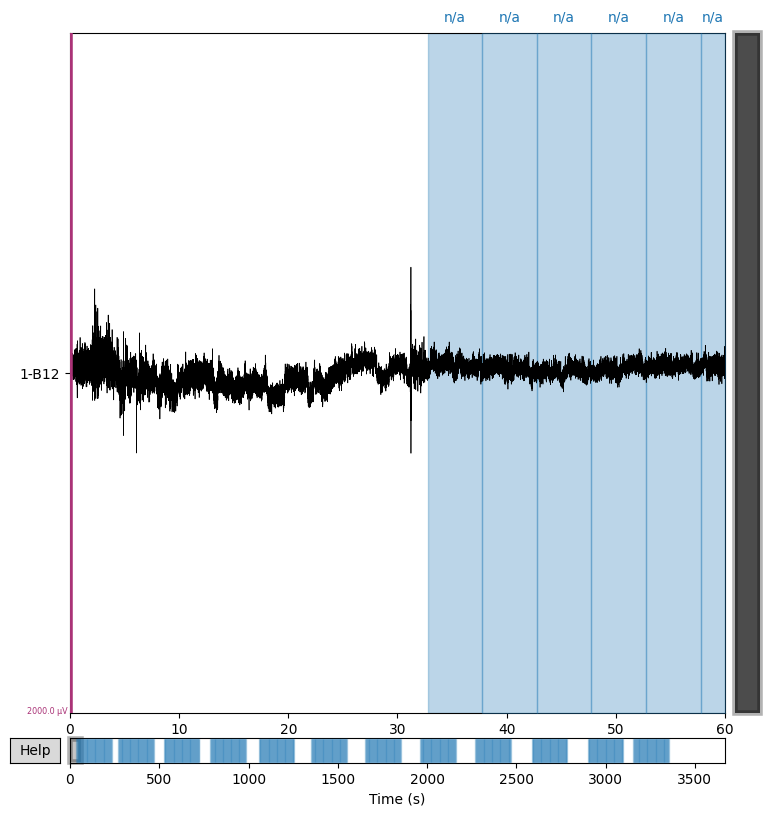

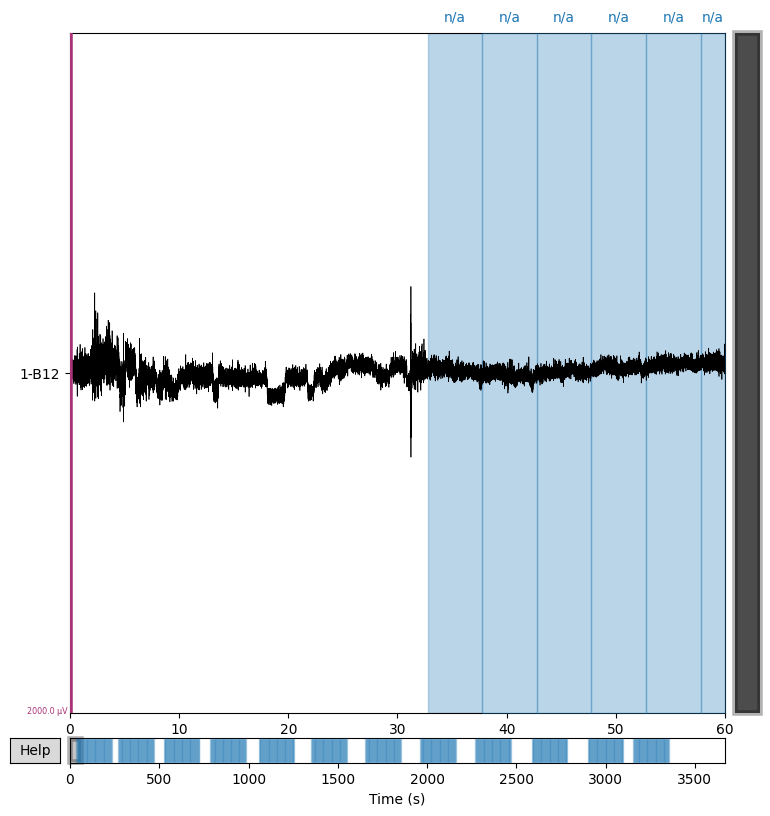

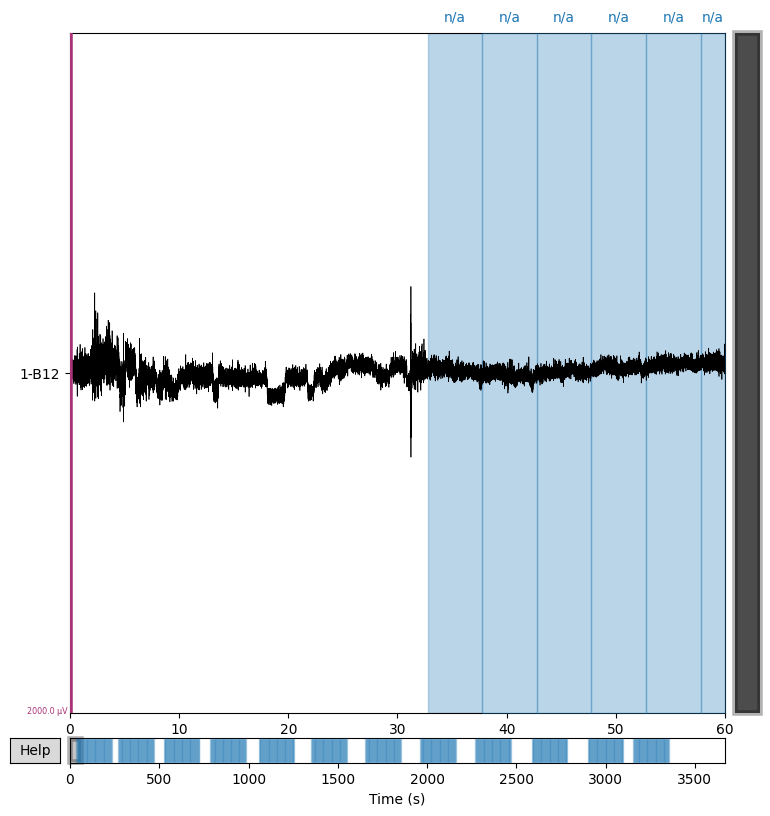

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd() / '..' / 'eeg_pipeline').resolve()))

import utils
from utils import load_raw

# --- Originaldaten ---
raw_orig = load_raw("../data/sub-01_P1_raw.fif")

# --- Re-referenzierte Daten ---
raw_reref = load_raw("../data/sub-01_P1_raw_CAR.fif")

# --- EEG-Kanäle auswählen ---
eeg_chs = [ch for ch in raw_orig.ch_names if ch.startswith("1-A") or ch.startswith("1-B")]
raw_orig.pick_channels([c for c in eeg_chs if c == '1-B16'])
raw_reref.pick_channels([c for c in eeg_chs if c == '1-B16'])

# --- Skalierung: z.B. ±100 µV, für alle Kanäle gleich ---
scaling = 1000e-6  # Volt

# --- Originalplot ---
raw_orig.plot(n_channels=len(eeg_chs), duration=60, scalings={'eeg': scaling}, title="Original P1")

# --- Re-referenced Plot ---
raw_reref.plot(n_channels=len(eeg_chs), duration=60, scalings={'eeg': scaling}, title="Re-referenced P1")